In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
#load dataset
df=pd.read_csv("/content/cardata - cardata.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.shape

(301, 9)

In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
#detect missing values
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
#count occurance of each Fuel_type in the dataset
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [ ]:
#count occurances of each seller_type in the dataset
df['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [ ]:
#count occurances of each transmission type in the dataset
df['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [ ]:
#onehot encoding
df=pd.get_dummies(df,columns=['Fuel_Type','Seller_Type','Transmission'])

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Owner', 'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Seller_Type_Dealer', 'Seller_Type_Individual',
       'Transmission_Automatic', 'Transmission_Manual'],
      dtype='object')

In [ ]:
 #create feature matrix x by dropping care_name and selling_price columns
 x=df.drop(['Car_Name','Selling_Price'],axis=1)
 #create target vector y by selecting selling_price column
 y=df['Selling_Price']

In [ ]:
x.head()

,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual
0,2014,5.59,27000,0,False,False,True,True,False,False,True
1,2013,9.54,43000,0,False,True,False,True,False,False,True
2,2017,9.85,6900,0,False,False,True,True,False,False,True
3,2011,4.15,5200,0,False,False,True,True,False,False,True
4,2014,6.87,42450,0,False,True,False,True,False,False,True


In [ ]:
y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [ ]:
#create the moel
model=LinearRegression()

In [ ]:
#train the model
model.fit(x,y)

LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42) # Using 20% for testing and a random_state for reproducibility

# Generate predictions for training and testing datasets using the trained model
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)
print("Predictions generated for both Train and Test sets.")

Predictions generated for both Train and Test sets.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
mae = mean_absolute_error(Y_train, Y_train_pred)
mse = mean_squared_error(Y_train, Y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_train, Y_train_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 1.1692187935526512
Mean Squared Error (MSE): 2.9718698904531613
Root MSE (RMSE): 1.723911218843117
R2 Score: 0.8875869613859126


In [ ]:
# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
mae = mean_absolute_error(Y_test, Y_test_pred)
mse = mean_squared_error(Y_test, Y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 1.1780981824759056
Mean Squared Error (MSE): 3.227201203438042
Root MSE (RMSE): 1.796441260781449
R2 Score: 0.8599036546871449


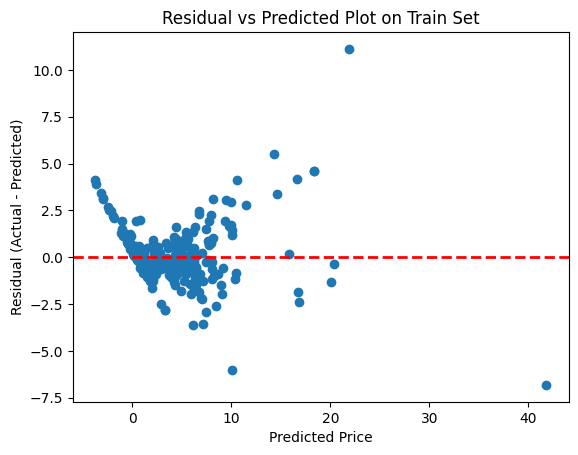

In [ ]:
# Plot residuals against predicted values on training data to analyze error patterns
residuals = Y_train - Y_train_pred
plt.scatter(Y_train_pred, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual vs Predicted Plot on Train Set")
plt.show()

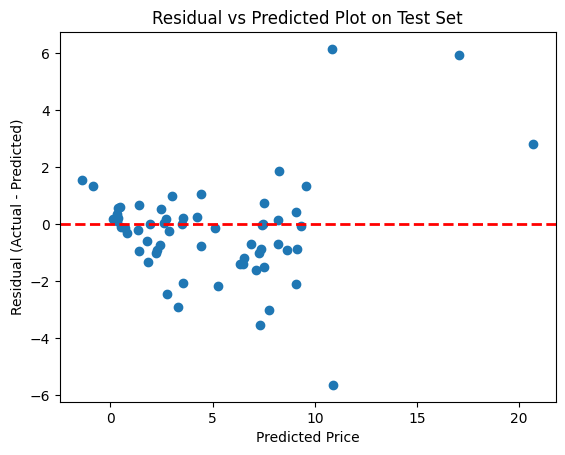

In [ ]:
# Plot residuals against predicted values on testing data to assess model generalization
residuals = Y_test - Y_test_pred
plt.scatter(Y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual vs Predicted Plot on Test Set")
plt.show()